# 뉴스 기사 데이터 전처리

## https://news.naver.com/

### 위 사이트에서 뉴스기사 하나를 선택하여 다음의 전처리 작업들을 수행해보세요.

문장/단어 토큰화: 기사를 적절한 구분자를 활용하여 문장과 단어 단위로 나눠보세요.

품사 부착: 각 단어에 품사 태그를 부착해보세요.

개체명 인식: 기사에서 인물, 장소, 조직 등의 개체명을 식별해보세요.

원형 복원: 어간 추출, 표제어 추출의 방식을 활용하여 각각 원형을 복원해보세요.

불용어 처리: 분석에 불필요한 불용어/품사 제거해보세요.



### 시각화

이후 전처리 된 데이터를 기반으로 가장 많이 등장한 단어를 시각화 해보세요.



### 전처리 결과에 대한 고찰

토큰화 과정에서 발생한 문제점과 이를 해결하기 위해서 찾아보았거나, 사용한 라이브러리에 대해 제안해보세요.

원형 복원이 필요한 이유에 대해서 생각해보고, 원형복원을 하지 않았을 때의 문제점에 대해서 설명해주세요.

데이터를 살펴보며 불용어 목록을 직접 구성해서 제거해보고, 이러한 불용어 목록을 직접 구성할 때 고려해야 할 사항에 대해서 고민해보세요.

불용어를 제거하지 않으면 분석 결과에 어떤 영향을 미치는지 설명해주세요.



In [5]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install requests


   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]

Note: you may need to restart the kernel to use updated packages.


In [7]:
import requests
from bs4 import BeautifulSoup

In [8]:
url = 'https://n.news.naver.com/article/661/0000083945?cds=news_media_pc&type=editn'
response = requests.get(url)
soup = BeautifulSoup(response.text,'html.parser')

In [11]:
kor_news = soup.select_one('#newsct_article')
kor_text = kor_news.get_text(strip=True)
print(kor_text)

연휴 닷새 내국인 17만 399명… 예상보다 2만 1,501명 적어국내선 38편·좌석 1만 5,449석 감소… 항공 공급 축소 이어져짧은 연휴에 일본 등 근거리 해외여행 수요… 제주와 경쟁 심화외국인은 15.3% 증가… 내·외국인 관광시장 흐름 엇갈려제주행 국내선 공급 감소와 근거리 해외여행 수요 흐름을 표현한 이미지. (AI 생성)추석 연휴에도 제주를 찾는 내국인 관광객 감소 흐름은 꺾이지 않았습니다.지난 23일부터 27일까지 닷새 동안 제주를 찾은 내국인은 17만 399명으로 잠정 집계됐습니다. 연휴 전 예상했던 19만 1,900명보다 2만 1,501명, 11.2% 적었습니다.추석이 포함된 9월 전체로 보면 내국인 관광객은 지난해 같은 기간보다 9.3% 줄었습니다.제주행 국내선 공급이 감소한 가운데 일본 등 가까운 해외로 향하는 여행 수요가 이어지면서 제주 내국인 관광시장의 부담도 커지는 모습입니다.■ 예상보다 내국인 2만 1,501명 적어28일 제주도관광협회 일일 관광객 입도현황에 따르면 지난 23일부터 27일까지 제주를 찾은 관광객은 모두 21만 2,503명으로 잠정 집계됐습니다.당초 예상했던 22만 9,000명보다 1만 6,497명, 7.2% 적습니다.이 기간 내국인은 닷새 동안 17만 399명이 제주를 찾았습니다.반면 외국인은 4만 2,104명으로 예상치보다 5,004명 많았습니다.외국인 입도객이 전망치를 웃돌았지만 내국인에서 더 큰 차이가 발생하면서 전체 관광객도 당초 예상에 미치지 못했습니다.■ 국내선 38편·좌석 1만 5,449석 줄어제주를 오가는 국내선 공급도 감소했습니다.이번 추석 연휴 국내선 운항계획은 1,105편으로 지난해보다 38편, 3.3% 줄었습니다. 공급좌석은 20만 8,865석으로 1만 5,449석, 6.9% 감소했습니다.국제선은 지난해보다 25편 늘어난 184편이 편성됐고 공급좌석도 14.8% 증가했습니다.연휴에만 국한된 흐름도 아닙니다.9월 김포~제주 노선 예정 공급좌석은 양방향 108만 4,920석으로 지난해 같은 달보다 

(1) 문장/단어 토큰화

In [12]:
!pip install konlpy

In [17]:
# Okt 토큰화
from konlpy.tag import Okt
okt= Okt()
okt_tokens = okt.morphs(kor_text)
print(okt_tokens)

['연휴', '닷새', '내', '국', '인', '17만', '399', '명', '…', '예상', '보다', '2만', '1,501', '명', '적어', '국내선', '38', '편', '·', '좌석', '1만', '5,449', '석', '감소', '…', '항공', '공급', '축소', '이어져', '짧은', '연휴', '에', '일본', '등', '근거리', '해외여행', '수요', '…', '제주', '와', '경쟁', '심화', '외국인', '은', '15.3%', '증가', '…', '내', '·', '외국인', '관광', '시장', '흐름', '엇갈려', '제', '주행', '국내선', '공급', '감소', '와', '근거리', '해외여행', '수요', '흐름', '을', '표현', '한', '이미지', '.', '(', 'AI', '생', '성', ')', '추석', '연휴', '에도', '제주', '를', '찾는', '내', '국', '인', '관광객', '감소', '흐름', '은', '꺾이지', '않았습니다', '.', '지난', '23일', '부터', '27일', '까지', '닷새', '동안', '제주', '를', '찾은', '내', '국', '인', '은', '17만', '399', '명', '으로', '잠정', '집계', '됐습니다', '.', '연휴', '전', '예상', '했던', '19만', '1,900', '명보', '다', '2만', '1,501', '명', ',', '11.2%', '적었습니다', '.', '추석', '이', '포함', '된', '9월', '전체', '로', '보면', '내', '국', '인', '관광객', '은', '지난해', '같은', '기간', '보다', '9.3%', '줄었습니다', '.', '제', '주행', '국내선', '공급', '이', '감소', '한', '가운데', '일본', '등', '가까운', '해외', '로', '향', '하는', '여행', '수요', '가', '이어지면서', '제

(2) 품사 부착

In [18]:
# Okt 품사 태깅
oktTag = []
for token in okt_tokens:
    oktTag += okt.pos(token)
print(oktTag)

[('연휴', 'Noun'), ('닷새', 'Noun'), ('내', 'Noun'), ('국', 'Noun'), ('인', 'Noun'), ('17만', 'Number'), ('399', 'Number'), ('명', 'Noun'), ('…', 'Punctuation'), ('예상', 'Noun'), ('보다', 'Verb'), ('2만', 'Number'), ('1,501', 'Number'), ('명', 'Noun'), ('적어', 'Verb'), ('국내선', 'Noun'), ('38', 'Number'), ('편', 'Noun'), ('·', 'Punctuation'), ('좌석', 'Noun'), ('1만', 'Number'), ('5,449', 'Number'), ('석', 'Noun'), ('감소', 'Noun'), ('…', 'Punctuation'), ('항공', 'Noun'), ('공급', 'Noun'), ('축소', 'Noun'), ('이어져', 'Verb'), ('짧은', 'Adjective'), ('연휴', 'Noun'), ('에', 'Josa'), ('일본', 'Noun'), ('등', 'Noun'), ('근거리', 'Noun'), ('해외여행', 'Noun'), ('수요', 'Noun'), ('…', 'Punctuation'), ('제주', 'Noun'), ('와', 'Verb'), ('경쟁', 'Noun'), ('심화', 'Noun'), ('외국인', 'Noun'), ('은', 'Noun'), ('15.3%', 'Number'), ('증가', 'Noun'), ('…', 'Punctuation'), ('내', 'Noun'), ('·', 'Punctuation'), ('외국인', 'Noun'), ('관광', 'Noun'), ('시장', 'Noun'), ('흐름', 'Noun'), ('엇갈려', 'Verb'), ('제', 'Noun'), ('주행', 'Noun'), ('국내선', 'Noun'), ('공급', 'Noun'), ('감소', 

(3) 개체명 인식: 기사에서 인물, 장소, 조직 등의 개체명을 식별

In [19]:
named_entities = []

for word, pos in oktTag:
    # Noun: 명사(인물/장소 포함), Alpha: 영문명, Number: 숫자 데이터
    if pos in ['Noun', 'Alpha', 'Number']:
        named_entities.append((word, pos))

print(named_entities)

[('연휴', 'Noun'), ('닷새', 'Noun'), ('내', 'Noun'), ('국', 'Noun'), ('인', 'Noun'), ('17만', 'Number'), ('399', 'Number'), ('명', 'Noun'), ('예상', 'Noun'), ('2만', 'Number'), ('1,501', 'Number'), ('명', 'Noun'), ('국내선', 'Noun'), ('38', 'Number'), ('편', 'Noun'), ('좌석', 'Noun'), ('1만', 'Number'), ('5,449', 'Number'), ('석', 'Noun'), ('감소', 'Noun'), ('항공', 'Noun'), ('공급', 'Noun'), ('축소', 'Noun'), ('연휴', 'Noun'), ('일본', 'Noun'), ('등', 'Noun'), ('근거리', 'Noun'), ('해외여행', 'Noun'), ('수요', 'Noun'), ('제주', 'Noun'), ('경쟁', 'Noun'), ('심화', 'Noun'), ('외국인', 'Noun'), ('은', 'Noun'), ('15.3%', 'Number'), ('증가', 'Noun'), ('내', 'Noun'), ('외국인', 'Noun'), ('관광', 'Noun'), ('시장', 'Noun'), ('흐름', 'Noun'), ('제', 'Noun'), ('주행', 'Noun'), ('국내선', 'Noun'), ('공급', 'Noun'), ('감소', 'Noun'), ('근거리', 'Noun'), ('해외여행', 'Noun'), ('수요', 'Noun'), ('흐름', 'Noun'), ('표현', 'Noun'), ('이미지', 'Noun'), ('AI', 'Alpha'), ('생', 'Noun'), ('성', 'Noun'), ('추석', 'Noun'), ('연휴', 'Noun'), ('제주', 'Noun'), ('를', 'Noun'), ('내', 'Noun'), ('국', 'Noun'), 

(4) 원형 복원

In [20]:
korean_stemmed = okt.morphs(kor_text, stem=True)
print("--- 한글 어간 추출 결과 ---")
print(korean_stemmed)

--- 한글 어간 추출 결과 ---
['연휴', '닷새', '내', '국', '인', '17만', '399', '명', '…', '예상', '보다', '2만', '1,501', '명', '적다', '국내선', '38', '편', '·', '좌석', '1만', '5,449', '석', '감소', '…', '항공', '공급', '축소', '이어지다', '짧다', '연휴', '에', '일본', '등', '근거리', '해외여행', '수요', '…', '제주', '와', '경쟁', '심화', '외국인', '은', '15.3%', '증가', '…', '내', '·', '외국인', '관광', '시장', '흐름', '엇갈리다', '제', '주행', '국내선', '공급', '감소', '와', '근거리', '해외여행', '수요', '흐름', '을', '표현', '한', '이미지', '.', '(', 'AI', '생', '성', ')', '추석', '연휴', '에도', '제주', '를', '찾다', '내', '국', '인', '관광객', '감소', '흐름', '은', '꺾다', '않다', '.', '지난', '23일', '부터', '27일', '까지', '닷새', '동안', '제주', '를', '찾다', '내', '국', '인', '은', '17만', '399', '명', '으로', '잠정', '집계', '돼다', '.', '연휴', '전', '예상', '하다', '19만', '1,900', '명보', '다', '2만', '1,501', '명', ',', '11.2%', '적다', '.', '추석', '이', '포함', '되다', '9월', '전체', '로', '보다', '내', '국', '인', '관광객', '은', '지난해', '같다', '기간', '보다', '9.3%', '줄다', '.', '제', '주행', '국내선', '공급', '이', '감소', '한', '가운데', '일본', '등', '가깝다', '해외', '로', '향', '하다', '여행', '수요', '가', 

In [21]:
korean_lemmatized = okt.pos(kor_text, stem=True)
print("\n--- 한글 표제어 추출 결과 (품사 보존) ---")
print(korean_lemmatized)


--- 한글 표제어 추출 결과 (품사 보존) ---
[('연휴', 'Noun'), ('닷새', 'Noun'), ('내', 'Determiner'), ('국', 'Noun'), ('인', 'Josa'), ('17만', 'Number'), ('399', 'Number'), ('명', 'Noun'), ('…', 'Punctuation'), ('예상', 'Noun'), ('보다', 'Josa'), ('2만', 'Number'), ('1,501', 'Number'), ('명', 'Noun'), ('적다', 'Verb'), ('국내선', 'Noun'), ('38', 'Number'), ('편', 'Noun'), ('·', 'Punctuation'), ('좌석', 'Noun'), ('1만', 'Number'), ('5,449', 'Number'), ('석', 'Noun'), ('감소', 'Noun'), ('…', 'Punctuation'), ('항공', 'Noun'), ('공급', 'Noun'), ('축소', 'Noun'), ('이어지다', 'Verb'), ('짧다', 'Adjective'), ('연휴', 'Noun'), ('에', 'Josa'), ('일본', 'Noun'), ('등', 'Noun'), ('근거리', 'Noun'), ('해외여행', 'Noun'), ('수요', 'Noun'), ('…', 'Punctuation'), ('제주', 'Noun'), ('와', 'Josa'), ('경쟁', 'Noun'), ('심화', 'Noun'), ('외국인', 'Noun'), ('은', 'Josa'), ('15.3%', 'Number'), ('증가', 'Noun'), ('…', 'Punctuation'), ('내', 'Noun'), ('·', 'Punctuation'), ('외국인', 'Noun'), ('관광', 'Noun'), ('시장', 'Noun'), ('흐름', 'Noun'), ('엇갈리다', 'Verb'), ('제', 'Modifier'), ('주행', 'Noun')

(5) 불용어 처리

In [22]:
from collections import Counter
Counter(oktTag).most_common()

[(('.', 'Punctuation'), 36),
 (('명', 'Noun'), 21),
 (('은', 'Noun'), 21),
 (('내', 'Noun'), 18),
 (('를', 'Noun'), 18),
 (('이', 'Noun'), 17),
 (('국', 'Noun'), 16),
 (('인', 'Noun'), 16),
 (('으로', 'Josa'), 15),
 (('보다', 'Verb'), 14),
 (('제주', 'Noun'), 14),
 (('연휴', 'Noun'), 13),
 (('가', 'Verb'), 13),
 (('감소', 'Noun'), 11),
 ((',', 'Punctuation'), 11),
 (('했습니다', 'Verb'), 11),
 (('국내선', 'Noun'), 9),
 (('공급', 'Noun'), 9),
 (('수요', 'Noun'), 9),
 (('지난해', 'Noun'), 9),
 (('외국인', 'Noun'), 8),
 (('추석', 'Noun'), 8),
 (('관광객', 'Noun'), 8),
 (('좌석', 'Noun'), 7),
 (('등', 'Noun'), 7),
 (('9월', 'Number'), 7),
 (('전체', 'Noun'), 7),
 (('도', 'Noun'), 7),
 (('석', 'Noun'), 6),
 (('에', 'Josa'), 6),
 (('일본', 'Noun'), 6),
 (('을', 'Josa'), 6),
 (('기간', 'Noun'), 6),
 (('예상', 'Noun'), 5),
 (('편', 'Noun'), 5),
 (('해외여행', 'Noun'), 5),
 (('와', 'Verb'), 5),
 (('흐름', 'Noun'), 5),
 (('까지', 'Josa'), 5),
 (('로', 'Noun'), 5),
 (('같은', 'Adjective'), 5),
 (('계', 'Noun'), 5),
 (('…', 'Punctuation'), 4),
 (('·', 'Punctuation')

In [23]:
stopPos = ['Suffix','Punctuation','Josa','Foreign','Alpha','Number']

In [42]:
stopWord = [
    '.', ',', '…', '·', '■', '↓', '“', '”', '~', '(', ')',
    '명', '은', '내', '를', '이', '국', '인', '으로', '보다', '가',
    '했습니다', '등', '도', '석', '에', '을', '편', '와', '까지', 
    '로', '계', '제', '한', '된', '는', '에는', '에서는', '의', '고', '지',
    '하는', '하고', '있습니다', '같은', '찾은', '됐습니다', '줄었습니다', '기록', '했구'
]

In [43]:
word = []
for tag in oktTag:
    if tag[1] not in stopPos:
        if tag[0] not in stopWord and len(tag[0])>1 :
            word.append(tag[0])

In [44]:
print(word)

['연휴', '닷새', '예상', '적어', '국내선', '좌석', '감소', '항공', '공급', '축소', '이어져', '짧은', '연휴', '일본', '근거리', '해외여행', '수요', '제주', '경쟁', '심화', '외국인', '증가', '외국인', '관광', '시장', '흐름', '엇갈려', '주행', '국내선', '공급', '감소', '근거리', '해외여행', '수요', '흐름', '표현', '이미지', '추석', '연휴', '제주', '찾는', '관광객', '감소', '흐름', '꺾이지', '않았습니다', '지난', '부터', '닷새', '동안', '제주', '잠정', '집계', '연휴', '예상', '했던', '명보', '적었습니다', '추석', '포함', '전체', '보면', '관광객', '지난해', '기간', '주행', '국내선', '공급', '감소', '가운데', '일본', '가까운', '해외', '여행', '수요', '이어지면서', '제주', '관광', '시장', '부담', '커지는', '모습', '입니다', '예상', '적어', '제주도', '관광', '협회', '일일', '관광객', '입도', '현황', '따르면', '지난', '부터', '제주', '관광객', '모두', '잠정', '집계', '당초', '예상', '했던', '명보', '적습니다', '기간', '닷새', '동안', '제주', '찾았습니다', '반면', '외국인', '상치', '많았습니다', '외국인', '입도', '망치', '돌았지만', '차이', '발생', '하면서', '전체', '관광객', '당초', '예상', '미치지', '국내선', '좌석', '줄어', '제주', '오가는', '국내선', '공급', '감소', '이번', '추석', '연휴', '국내선', '운항', '계획', '지난해', '공급', '좌석', '감소', '국제선', '지난해', '늘어난', '편이', '편성', '됐고', '공급', '좌석', '증가', '연휴', '국한', '흐름', '아닙니다

## 시각화

In [38]:
!pip install wordcloud

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -------------------------------------- - 7.6/7.8 MB 47.1 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 30.2 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 80.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 106.7 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ------------- -------------------------- 3/9 [importlib-resources]
   ----------------- ---------------------- 4/9 [fonttools]
   ----------------- ---------------------- 4/9 [fonttools]
   --------------

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

In [45]:
counts = Counter(word)

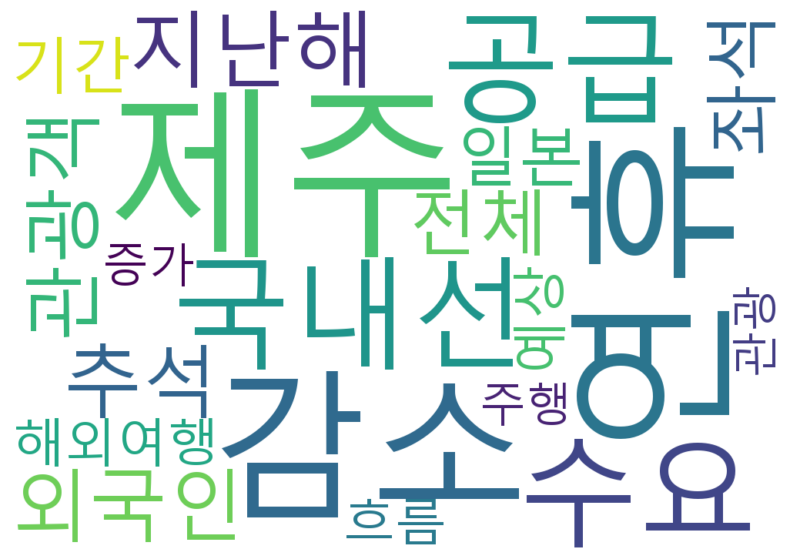

In [49]:
top_counts = dict(counts.most_common(20))
wordcloud = WordCloud(
    font_path='C:/windows/Fonts/malgun.ttf',
    background_color='white',
    width=1000,              
    height=700,
    max_words=20,                   
    colormap='viridis'       
).generate_from_frequencies(top_counts)


plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

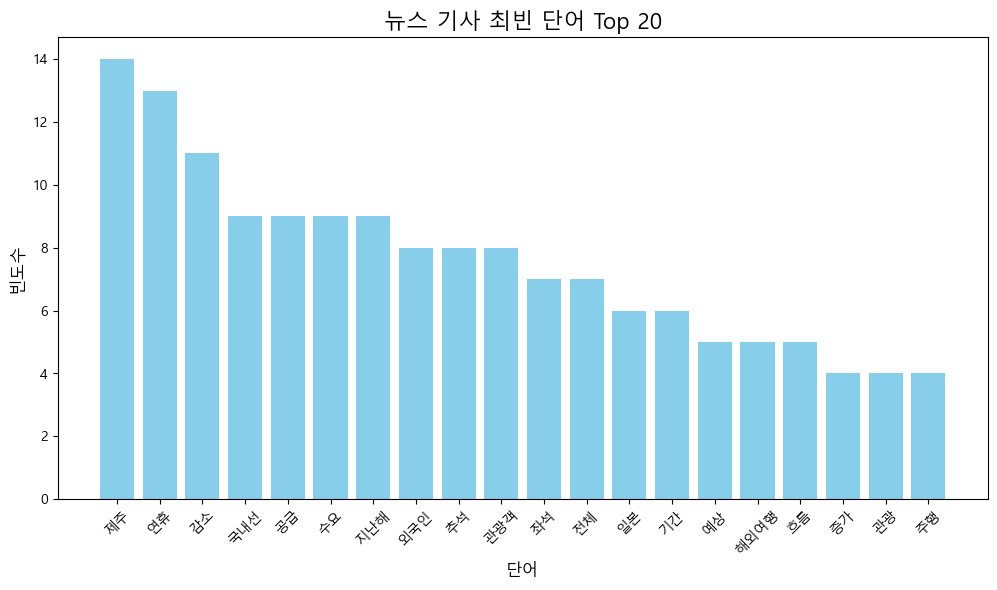

In [51]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

counts = Counter(word)
top_words = counts.most_common(20)
words = [word for word, count in top_words]
values = [count for word, count in top_words]


plt.figure(figsize=(12, 6))
plt.bar(words, values, color='skyblue')
plt.title('뉴스 기사 최빈 단어 Top 20', fontsize=16)
plt.xlabel('단어', fontsize=12)
plt.ylabel('빈도수', fontsize=12)
plt.xticks(rotation=45)
plt.show()

[전처리 결과에 대한 고찰]

1. 토큰화 과정에서 발생한 문제점과 해결 라이브러리 제안
    - 발생한 문제점: 한국어는 영어와 달리 조사와 어미가 명사에 붙어 변하는 교착어입니다. 이로 인해 단순 공백(띄어쓰기)만으로 토큰화를 진행하면 '내국인', '내국인은', '내국인이'가 모두 서로 다른 단어로 인식되어 형태소 분리가 제대로 이루어지지 않는 한계가 발생했습니다. 
    또한, 문장 부호(., ,, …)나 숫자, 단위 명사(명, 석)가 핵심 의미를 가진 명사와 결합하여 분리되지 않는 문제가 있었습니다.
    - 해결 및 사용 라이브러리 제안: 이를 해결하기 위해 한국어 자연어 처리 전용 형태소 분석 패키지인 KoNLPy를 도입했습니다. 특히 문맥 파악 속도가 빠르고 인터넷 신조어나 오탈자 정제에 강한 Okt 분석기를 활용하여, 의미 있는 형태소 단위로 토큰화를 정상 수행할 수 있었습니다.
    
2. 원형 복원이 필요한 이유와 하지 않았을 때의 문제점
    - 원형 복원이 필요한 이유: 텍스트 내에서 다양한 어미 변화를 겪는 동사와 형용사(예: '적어', '적었습니다', '적습니다')를 하나의 기본 사전형 단어(예: '적다')로 통일하기 위해 필요합니다. 
    품사 고유의 문법적 의미를 보존하면서 단어들을 표준화해야 정확한 의미 분석이 가능해집니다.
    - 하지 않았을 때의 문제점: 원형 복원을 생략하면 동일한 어근을 가진 단어들이 어미 변화에 따라 각각 다른 단어로 취급됩니다.
    이로 인해 단어의 빈도수(Frequency)가 분산되어, 분석 결과에서 핵심 키워드의 가중치가 왜곡되거나 가장 중요한 단어가 최빈어 순위에서 누락되는 정보 손실 문제가 발생합니다.
    
3. 불용어 목록 구성 시 고려해야 할 사항
    - 직접 구성한 불용어 처리 방식: stopPos 배열을 선언하여 접사, 구두점, 조사, 외래어, 숫자 관련 품사('Suffix', 'Punctuation', 'Josa', 'Foreign', 'Alpha', 'Number')를 일차적으로 필터링했습니다.
    이후 빈도수는 높으나 기사의 고유 주제를 나타내지 못하는 단어들('명', '은', '내', '를', '등', '했습니다' 등)을 stopWord 목록에 직접 추가하여 2글자 이상인 핵심 단어만 남기도록 제안·구현했습니다.
    - 불용어 목록 구성 시 고려사항
        1) 도메인(도메인 특수성) 고려: 해당 데이터가 속한 분야의 특성을 고려해야 합니다. 예를 들어 일반 문서에서 '제주', '연휴'는 흔한 단어일 수 있지만, 이번 뉴스 기사에서는 핵심 주제어이므로 불용어에서 반드시 제외해야 합니다.
        2) 의미 없는 고빈도어 필터링: 문장 구조를 형성하기 위해 형식적으로 자주 사용되는 기능어(조사, 대명사, 보조 용언)가 중요 명사로 오인되지 않도록 사전에 철저히 수집해야 합니다.

4. 불용어를 제거하지 않았을 때 분석 결과에 미치는 영향
    - 의미 없는 단어의 상위권 독점: 불용어를 제거하지 않으면 최빈어 조회 결과에서 구두점(., ,)이나 조사(은, 를, 이, 으로)와 같은 기능어들이 빈도수 상위권을 모두 독점하게 됩니다.
    - 핵심 주제 파악 방해 및 시각화 왜곡: 워드클라우드나 막대그래프 시각화 시, '제주', '연휴', '감소', '국내선' 같은 뉴스의 진짜 핵심 키워드들이 가려져 보이지 않게 됩니다. 
    결과적으로 데이터의 특징을 요약하고 인사이트를 도출해야 하는 텍스트 마이닝 본연의 목적을 달성할 수 없게 됩니다.